In [1]:
%pip install sentencepiece

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("1. Đang nạp dữ liệu từ file CSV gốc...")
df = pd.read_csv("clickbait_dataset_vietnamese.csv") 

# BỘ DỊCH NHÃN: Chuyển đổi nhãn (dạng chữ/chuỗi) thành dạng số nguyên (0 và 1)
encoder = LabelEncoder()
df['label_encoded'] = encoder.fit_transform(df['label'])

print(f"🛠️ Đã quy đổi nhãn chữ thành số: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")

texts = df['title'].tolist()
# Sử dụng cột nhãn đã được mã hóa thành số
labels = df['label_encoded'].tolist() 

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)
print(f"✅ Đã chia xong: {len(train_texts)} câu để huấn luyện, {len(test_texts)} câu để kiểm tra.")

1. Đang nạp dữ liệu từ file CSV gốc...
🛠️ Đã quy đổi nhãn chữ thành số: {'clickbait': np.int64(0), 'non-clickbait': np.int64(1)}
✅ Đã chia xong: 2731 câu để huấn luyện, 683 câu để kiểm tra.


In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print("2. Đang tải cấu trúc mô hình XLM-RoBERTa Base...")
# Khóa hạt giống ngẫu nhiên để cố định kết quả
torch.manual_seed(42)

model_name = "xlm-roberta-base"

# XLM-R dùng bộ Tokenizer riêng, khác với vELECTRA
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2, 
    use_safetensors=True
)
print("✅ Tải mô hình thành công!")

2. Đang tải cấu trúc mô hình XLM-RoBERTa Base...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Tải mô hình thành công!


In [4]:
from datasets import Dataset

print("3. Đang cắt từ và đóng gói dữ liệu cho máy học...")
train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels})
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels})

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)
print("✅ Đóng gói hoàn tất!")

3. Đang cắt từ và đóng gói dữ liệu cho máy học...


Map:   0%|          | 0/2731 [00:00<?, ? examples/s]

Map:   0%|          | 0/683 [00:00<?, ? examples/s]

✅ Đóng gói hoàn tất!


In [5]:
import numpy as np
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary', zero_division=0)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

print("4. Đang cấu hình siêu tham số (Tối ưu cho VRAM 4GB)...")
training_args = TrainingArguments(
    output_dir='./xlmr_temp_checkpoints', 
    num_train_epochs=50,               
    per_device_train_batch_size=4,     # Chỉ nạp 4 câu 1 lần để cứu GPU
    gradient_accumulation_steps=4,     # Gom 4 lần 4 = 16 câu rồi mới cập nhật
    per_device_eval_batch_size=4,    
    learning_rate=1e-5,                
    logging_strategy="epoch",          
    eval_strategy="epoch",           
    save_strategy="epoch",           
    load_best_model_at_end=True,       
    metric_for_best_model="accuracy", 
    save_total_limit=1,                
    fp16=True,                         
    seed=42,                           
    report_to="none"                 
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] 
)

print("🚀 BẮT ĐẦU HUẤN LUYỆN (Sẽ tốn thời gian hơn vELECTRA một chút)...")
trainer.train()

4. Đang cấu hình siêu tham số (Tối ưu cho VRAM 4GB)...
🚀 BẮT ĐẦU HUẤN LUYỆN (Sẽ tốn thời gian hơn vELECTRA một chút)...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,2.332576,0.436504,0.819912,0.881617,0.826715,0.944330
2,1.796548,0.349606,0.838946,0.881974,0.919463,0.847423
3,1.496678,0.352990,0.844802,0.893788,0.869396,0.919588
4,1.210762,0.377884,0.855051,0.898462,0.893878,0.903093
5,1.087214,0.391631,0.838946,0.878855,0.943262,0.822680
6,0.880488,0.541555,0.850659,0.893528,0.904863,0.882474
7,0.727641,0.638010,0.841874,0.884615,0.917960,0.853608


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1197, training_loss=1.361701028388843, metrics={'train_runtime': 5202.7716, 'train_samples_per_second': 26.246, 'train_steps_per_second': 1.643, 'total_flos': 1257473511329280.0, 'train_loss': 1.361701028388843, 'epoch': 7.0})

In [7]:
import os

print("\n5. Đang lưu siêu mô hình vào ổ cứng...")
# Đã đổi tên thư mục thành "xlmr" theo đúng yêu cầu của bạn
thu_muc_luu = "./xlmr"
trainer.save_model(thu_muc_luu)
tokenizer.save_pretrained(thu_muc_luu)
print(f"✅ Đã lưu xong mô hình tại: {thu_muc_luu}")

print("\n6. Đang trích xuất lịch sử huấn luyện ra file CSV...")
log_history = trainer.state.log_history
log_data = {}

for entry in log_history:
    if 'epoch' in entry:
        ep = int(round(entry['epoch']))
        if ep not in log_data:
            log_data[ep] = {'Epoch': ep}
        if 'loss' in entry:
            log_data[ep]['Training Loss'] = entry['loss']
        if 'eval_loss' in entry:
            log_data[ep]['Validation Loss'] = entry['eval_loss']
            log_data[ep]['Accuracy'] = entry['eval_accuracy']
            log_data[ep]['F1'] = entry['eval_f1']
            log_data[ep]['Precision'] = entry['eval_precision']
            log_data[ep]['Recall'] = entry.get('eval_recall', entry.get('eval_eval_recall', ''))

# Xuất ra file xlmr_results.csv
df_logs = pd.DataFrame(list(log_data.values()))
if 'Validation Loss' in df_logs.columns:
    df_logs = df_logs.dropna(subset=['Validation Loss'])

ten_file_csv = "xlmr_results.csv"
df_logs.to_csv(ten_file_csv, index=False)

print(f"✅ Đã xuất file báo cáo thành công: {ten_file_csv}")



5. Đang lưu siêu mô hình vào ổ cứng...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Đã lưu xong mô hình tại: ./xlmr

6. Đang trích xuất lịch sử huấn luyện ra file CSV...
✅ Đã xuất file báo cáo thành công: xlmr_results.csv


Đang phân tích dữ liệu từ file xlmr_results.csv...
🏆 MÁY TÍNH XÁC NHẬN: Best Epoch của bạn là vòng số 4!


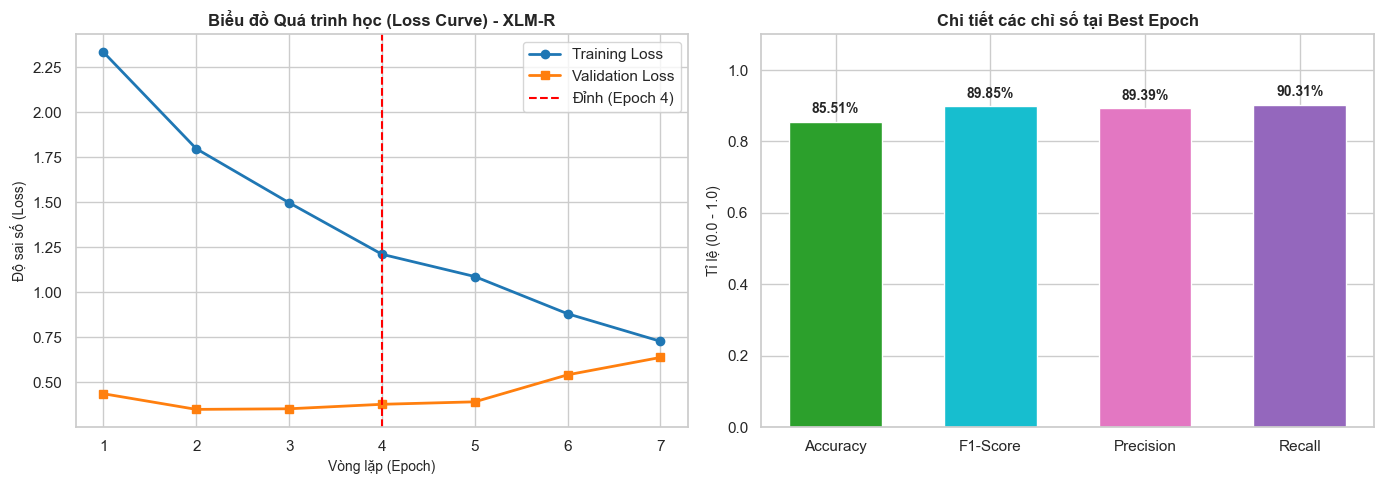

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Đang phân tích dữ liệu từ file xlmr_results.csv...")
# 1. Đọc dữ liệu
df = pd.read_csv("xlmr_results.csv")

# 2. Tìm Best Epoch (Vòng có độ chính xác - Accuracy cao nhất)
best_epoch_row = df.loc[df['Accuracy'].idxmax()]
best_epoch_num = int(best_epoch_row['Epoch'])

print(f"🏆 MÁY TÍNH XÁC NHẬN: Best Epoch của bạn là vòng số {best_epoch_num}!")

# 3. Cài đặt giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5)) # Kích thước ảnh ngang để chèn vừa vặn vào Word

# --- BIỂU ĐỒ 1: QUÁ TRÌNH HỌC (LOSS CURVE) ---
plt.subplot(1, 2, 1)
# Vẽ đường Train Loss và Val Loss
plt.plot(df['Epoch'], df['Training Loss'], label='Training Loss', marker='o', color='#1f77b4', linewidth=2)
plt.plot(df['Epoch'], df['Validation Loss'], label='Validation Loss', marker='s', color='#ff7f0e', linewidth=2)

# Vẽ một đường gạch dọc màu đỏ để đánh dấu chính xác điểm dừng sớm (Best Epoch)
plt.axvline(x=best_epoch_num, color='red', linestyle='--', label=f'Đỉnh (Epoch {best_epoch_num})')

plt.title('Biểu đồ Quá trình học (Loss Curve) - XLM-R', fontsize=12, fontweight='bold')
plt.xlabel('Vòng lặp (Epoch)', fontsize=10)
plt.ylabel('Độ sai số (Loss)', fontsize=10)
plt.legend()

# --- BIỂU ĐỒ 2: ĐIỂM SỐ TẠI BEST EPOCH ---
plt.subplot(1, 2, 2)
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
scores = [best_epoch_row['Accuracy'], best_epoch_row['F1'], best_epoch_row['Precision'], best_epoch_row['Recall']]

# Đổ màu cho từng cột cho sinh động
colors = ['#2ca02c', '#17becf', '#e377c2', '#9467bd']
bars = plt.bar(metrics, scores, color=colors, width=0.6)

plt.ylim(0, 1.1) # Giới hạn trục Y từ 0 đến 1.1 để có không gian ghi số
plt.title(f'Chi tiết các chỉ số tại Best Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Tỉ lệ (0.0 - 1.0)', fontsize=10)

# Ghi chính xác con số lên đỉnh mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.015, f"{round(yval*100, 2)}%", 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()